Neural Network without using Tensorflow or Pytorch
==============

**Author:** *Aaron Bui*


This neural network contains 1 input layer, 1 hidden layer, 1 output layer. RELU (Rectified Linear Unit) and Loss (MSE - Mean Squared Error)

📐 ReLU Derivative (Used in Backprop)

![CleanShot 2025-06-25 at 12.26.31@2x.png](<attachment:CleanShot 2025-06-25 at 12.26.31@2x.png>)

In backpropagation, the gradient is a measure of how much the loss (error) changes with respect to each parameter (weight or bias) in the neural network. In simple terms, it tells you:

“If I slightly change this weight, how will the loss increase or decrease?”

The goal of training a neural network is to minimize the loss function (how wrong the model is). To do this, we use gradient descent, which relies on gradients to decide:

Which direction to move the weights

By how much (scaled by the learning rate)

🧠 Backpropagation Role
During backpropagation:

Forward pass: Compute the output and the loss

Backward pass:

Use the chain rule to compute gradients layer by layer:

![CleanShot 2025-06-25 at 12.31.58@2x.png](<attachment:CleanShot 2025-06-25 at 12.31.58@2x.png>)

where 𝑧
z is some intermediate output

These gradients are then used to update the weights:

![CleanShot 2025-06-25 at 12.32.39@2x.png](<attachment:CleanShot 2025-06-25 at 12.32.39@2x.png>)

where 𝜂
η is the learning rate

✅ Summary
Gradient = slope of loss with respect to each parameter

Backpropagation = algorithm to compute all gradients efficiently

Used in: gradient descent to optimize weights
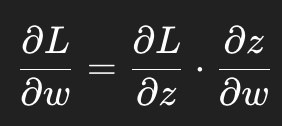
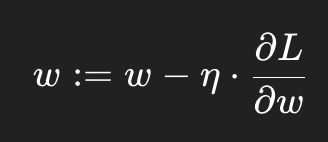

Install library

In [5]:
!python -m venv tf-env
!python --version

Python 3.10.0


In [12]:
!.\tf-env\Scripts\activate
!python --version
%pip install jupyter ipykernel
!python -m ipykernel install --user --name=tf-env --display-name "Python (tf-env)"


Python 3.10.0
  Using cached argon2_cffi_bindings-21.2.0-cp36-abi3-win_amd64.whl (30 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

Installed kernelspec tf-env in C:\Users\Admin\AppData\Roaming\jupyter\kernels\tf-env


In [13]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [14]:
import numpy as np

# --- Data ---
X = np.array([[1], [2], [3]], dtype=float)  # Inputs
Y = np.array([[3], [5], [7]], dtype=float)  # Targets (2x + 1)

# --- Initialize weights and biases ---
np.random.seed(42)
w1 = np.random.randn(1, 3)   # Input → hidden (1 input, 3 neurons)
b1 = np.zeros((1, 3))

w2 = np.random.randn(3, 1)   # Hidden → output (3 neurons, 1 output)
b2 = np.zeros((1, 1))

# --- Hyperparameters ---
lr = 0.01
epochs = 1000

# --- Activation functions ---
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

# --- Training ---
for epoch in range(epochs):
    # Forward pass
    z1 = X @ w1 + b1        # Input to hidden
    a1 = relu(z1)           # Activation
    z2 = a1 @ w2 + b2       # Hidden to output
    y_pred = z2             # No activation in output layer

    # Loss (Mean Squared Error)
    loss = np.mean((y_pred - Y) ** 2)

    # Backward pass
    dL_dy = 2 * (y_pred - Y) / len(X)     # MSE derivative

    # Gradients for output layer
    dw2 = a1.T @ dL_dy
    db2 = np.sum(dL_dy, axis=0, keepdims=True)

    # Gradients for hidden layer
    da1 = dL_dy @ w2.T
    dz1 = da1 * relu_deriv(z1)

    dw1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update weights
    w2 -= lr * dw2
    b2 -= lr * db2
    w1 -= lr * dw1
    b1 -= lr * db1

    # Print loss occasionally
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# --- Final Prediction ---
print("Final predictions:")
print(y_pred)


Epoch 0: Loss = 15.6638
Epoch 100: Loss = 0.0015
Epoch 200: Loss = 0.0002
Epoch 300: Loss = 0.0000
Epoch 400: Loss = 0.0000
Epoch 500: Loss = 0.0000
Epoch 600: Loss = 0.0000
Epoch 700: Loss = 0.0000
Epoch 800: Loss = 0.0000
Epoch 900: Loss = 0.0000
Final predictions:
[[2.99999419]
 [4.99999877]
 [7.00000335]]


---------------------------------------------------------------------------------------------------------------
***Building Neural Network using Tensorflow***

In [19]:
%pip install --user tensorflow

  Using cached tensorflow-2.19.0-cp310-cp310-win_amd64.whl (375.7 MB)
  Using cached grpcio-1.73.1-cp310-cp310-win_amd64.whl (4.3 MB)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp310-cp310-win_amd64.whl (1.5 MB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
  Using cached gast-0.6.0-py3-none-any.whl (21 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached keras-3.10.0-py3-none-any.whl (1.4 MB)
  Using cached wrapt-1.17.2-cp310-cp310-win_amd64.whl (38 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl (5.5 MB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached ml_dtypes-0.5.1-cp310-cp310-win_amd64.whl (209 kB)
  Using cached absl_py-2.3.0-py3-none-any.whl (135 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl (26.4 MB)
  Using cached protobuf-5.29.5-cp310-abi3-win_amd64.whl (434 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl (7.7 kB)
  U

You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [20]:
import tensorflow as tf
import numpy as np

# --- Data ---
X = np.array([[1], [2], [3]], dtype=float)
Y = np.array([[3], [5], [7]], dtype=float)

# --- Build the model ---
model = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation='relu', input_shape=(1,)),  # hidden layer with 3 neurons
    tf.keras.layers.Dense(1)  # output layer
])

# --- Compile the model ---
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),      
              loss='mean_squared_error')

# --- Train the model ---
model.fit(X, Y, epochs=1000, verbose=0)

# --- Predict ---
print("Final predictions:")
print(model.predict(X))

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[2.999934 ]
 [4.9999857]
 [7.000038 ]]


| Stretch/Untouched | ProbDistribution | Accuracy |
| --- | --- | --- |
| Stretched | Gaussian | .843 |

In [21]:
import numpy as np

# Create a 3x2 table with the specified values
table = np.array([
    [1, 4.9999886],
    [2, 4.9999886],
    [3, 4.9999886]
], dtype=float)

print(table)

[[1.        4.9999886]
 [2.        4.9999886]
 [3.        4.9999886]]


---------------------------------------------------------------------------------------------------------------
***Building Neural Network using Pytorch***

In [22]:
%pip install --user torch 

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Data ---
X = torch.tensor([[1.0], [2.0], [3.0]])
Y = torch.tensor([[3.0], [5.0], [7.0]])

# --- Define the model ---
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(1, 3)   # 1 input → 3 neurons
        self.output = nn.Linear(3, 1)   # 3 → 1 output

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return self.output(x)

model = SimpleNN()

# --- Loss and optimizer ---
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# --- Training loop ---
for epoch in range(1000):
    model.train()

    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, Y)

    # Backward pass and update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

# --- Final prediction ---
model.eval()
with torch.no_grad():
    predictions = model(X)
    print("Final predictions:")
    print(predictions)


Epoch 0: Loss = 41.5227
Epoch 100: Loss = 0.0011
Epoch 200: Loss = 0.0002
Epoch 300: Loss = 0.0001
Epoch 400: Loss = 0.0000
Epoch 500: Loss = 0.0000
Epoch 600: Loss = 0.0000
Epoch 700: Loss = 0.0000
Epoch 800: Loss = 0.0000
Epoch 900: Loss = 0.0000
Final predictions:
tensor([[2.9999],
        [5.0000],
        [7.0000]])


🔁 Epochs & Loss
Each epoch is one full pass through the training data. You trained for 1000 epochs.

Here’s what the loss tells us:

Epoch 0:   Loss = 41.5227   ← Very high error (model guesses poorly at start)

Epoch 100: Loss = 0.0011    ← Model is rapidly learning

Epoch 200: Loss = 0.0002    ← Very low error

Epoch 300+: Loss ≈ 0.0000   ← Model basically perfect

The loss is the Mean Squared Error (MSE):

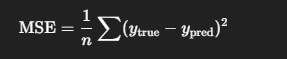
 
It starts high because weights are randomly initialized

It quickly converges (loss drops to ~0) as gradient descent optimizes the weights

📈 Final Predictions

tensor([[2.9999],
        [5.0000],
        [7.0000]])

These are the predictions for the inputs:

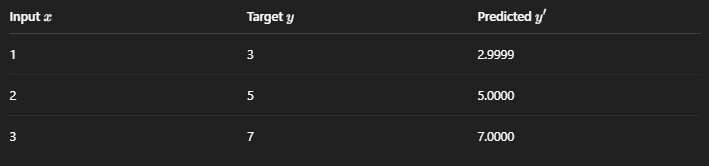
 
These are almost perfect, so the model has successfully learned the function:

y=2x+1

✅ Summary
Model started with random weights → high loss

Gradually learned the function through training → loss minimized

Final predictions ≈ targets → ✅ perfect fit